In [1]:
import pickle
import numpy as np
import tools_file
import tools_plot

convention = {
    "X": "+Z",
    "Y": "-X",
    "Z": "-Y",
}

TARGET_FPS = 200
PADDING = True

# 构造 convention shift 矩阵
P_SHIFT = np.array([0, 0, 0])
R_SHIFT = np.array([[0, 0, 1], 
                    [-1, 0, 0], 
                    [0, -1, 0]])
TF_SHIFT = np.eye(4)
TF_SHIFT[:3, :3] = R_SHIFT
TF_SHIFT[:3, 3] = P_SHIFT



dict_keys(['t', 'ee_pos', 'ee_axis_angle', 'gripper_width', 'linear_velocity', 'linear_acceleration', 'angular_velocity'])


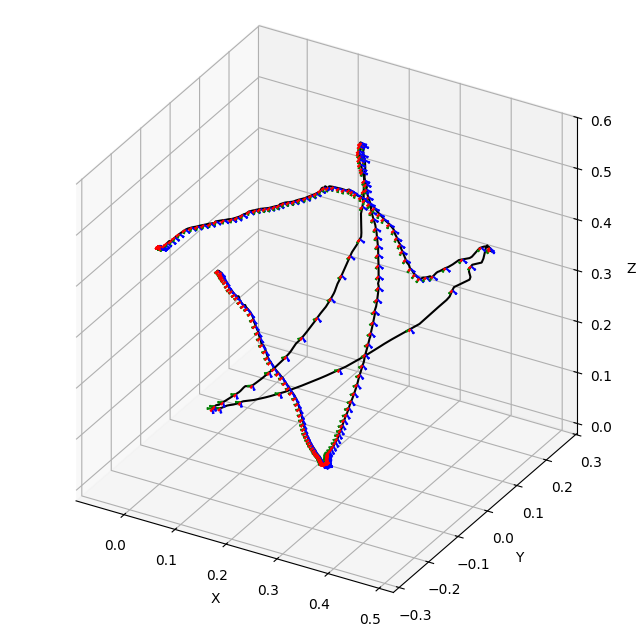

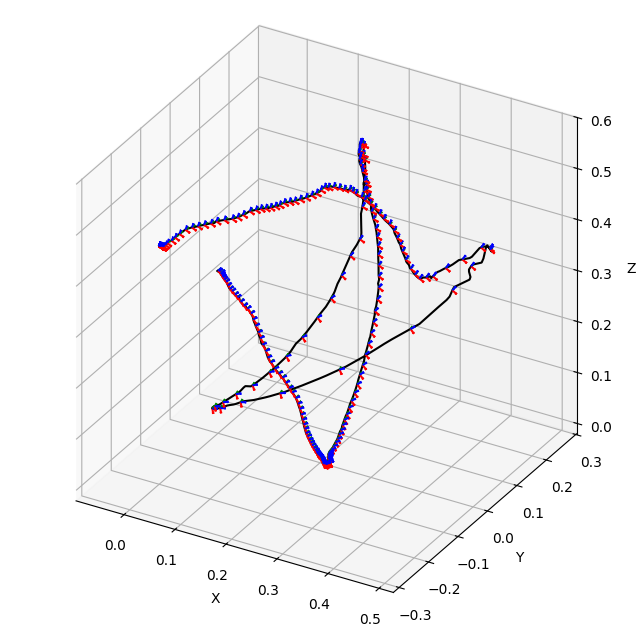

In [2]:
pkl_path = "data/tossing.pkl"
tf_umi = tools_file.pkl_to_tf(pkl_path)

umi_source_data = pickle.load(open(pkl_path, "rb"))
print(umi_source_data[0].keys())

tools_plot.plot_3d(tf_umi[0]["tf"])
tools_plot.plot_3d(tf_umi[0]["tf"] @ TF_SHIFT.T)

### Correct UMI trajectory convention

In [ ]:
tf_umi_mod = []
for item in tf_umi:
    tf_umi_mod.append({
        "t": item["t"],
        "tf": item["tf"] @ TF_SHIFT.T,
        "gripper_width": item["gripper_width"],
    })

tf_umi_mod = tools_file.tf_resample_tf(tf_umi_mod, TARGET_FPS, PADDING)

tf_list = tools_file.tf_to_traj(tf_umi_mod)
pickle.dump(tf_list, open("data/tossing_converted.pkl", "wb"))


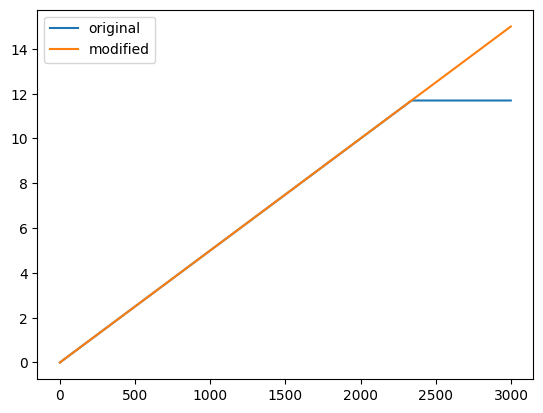

In [4]:
tf_umi_mod[0]['t']
import matplotlib.pyplot as plt
plt.plot(tf_umi[0]['t'], label='original')
plt.plot(tf_umi_mod[0]['t'], label='modified')
plt.legend()

### Double Check

200


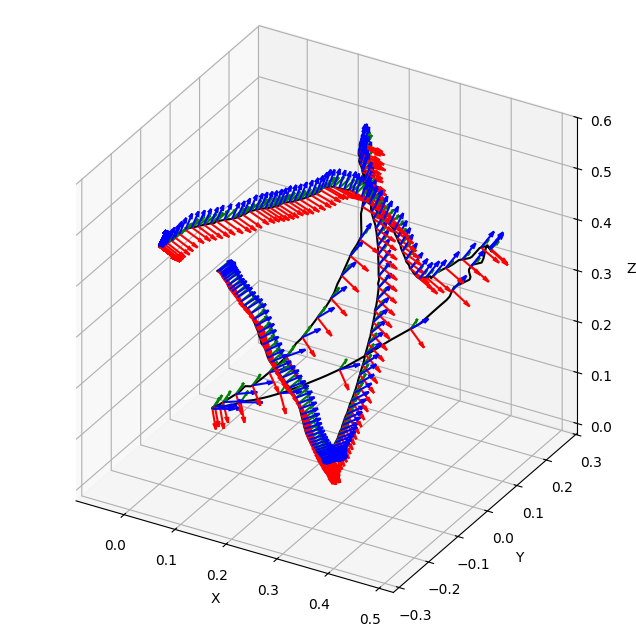

In [5]:
tf_list = tools_file.pkl_to_tf("data/tossing_converted.pkl")
print(tools_file.get_fps(tf_list))
tools_plot.plot_3d(tf_list[0]["tf"], arrow_length=0.2)